# 1. Data preparation

Loading data from source

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import PIL
import tensorflow as tf
import pathlib
import tensorflow.keras.layers as tfl
import os
import pickle
import keras_tuner as kt

In [3]:
from zipfile import ZipFile

# uncomment to load data
# zip_dir = 'data/emotion_data.zip'
# extraction_dir = ""

# with ZipFile(zip_dir, 'r') as zip_object:
#     zip_object.extractall(path=extraction_dir)

# print(f"All files extracted from '{zip_dir}' to '{extraction_dir}'.")

data_dir = pathlib.Path("emotion_data/")

Viewing training data

In [4]:
num_train_images = len(list(data_dir.glob("train/*/*")))
print("Images:", num_train_images)
print("Classes:", list(data_dir.glob("train/*")))

Images: 28709
Classes: [WindowsPath('emotion_data/train/angry'), WindowsPath('emotion_data/train/disgust'), WindowsPath('emotion_data/train/fear'), WindowsPath('emotion_data/train/happy'), WindowsPath('emotion_data/train/neutral'), WindowsPath('emotion_data/train/sad'), WindowsPath('emotion_data/train/surprise')]


In [5]:
train_dir = pathlib.Path("emotion_data/train")

batch_size = 64
# img_height = 180
# img_width = 180
val_split = 0.2

train_ds, val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=val_split,
    subset="both",
    seed=91,
    image_size=(48,48),
    batch_size=batch_size,
    color_mode='rgb',
    shuffle=True,
    label_mode='categorical'
)
# train_ds = train_ds.shuffle(buffer_size=len(list(train_ds.as_numpy_iterator())))
# val_ds = val_ds.shuffle(buffer_size=len(list(val_ds.as_numpy_iterator())))

Found 28709 files belonging to 7 classes.
Using 22968 files for training.
Using 5741 files for validation.


## Training preparation

In [6]:
class_names = train_ds.class_names
image_shape = None
labels_shape = None
num_classes = len(class_names)

for image_batch, labels_batch in train_ds:
    image_shape = image_batch.shape[1:]
    labels_shape = labels_batch.numpy().shape[1:]
    print(image_batch.shape, labels_batch.shape)
    break

print(class_names, image_shape, labels_shape)

(64, 48, 48, 3) (64, 7)
['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise'] (48, 48, 3) (7,)


Dataset configuration

In [7]:
AUTOTUNE = tf.data.AUTOTUNE

subset_reduction_factor_train = 0.2
subset_reduction_factor_val = 0.2
num_batches = num_train_images//batch_size

train_subset_size = int(num_batches*(1-val_split)*subset_reduction_factor_train)
val_subset_size = int(num_batches*val_split*subset_reduction_factor_val)

used_train_ds = train_ds.cache().take(train_subset_size).prefetch(buffer_size=AUTOTUNE)
used_val_ds = val_ds.cache().take(val_subset_size).prefetch(buffer_size=AUTOTUNE)

train_subset_size, val_subset_size

(71, 17)

Viewing training and validation data to ensure similar representations

# 2. Training

## Utilities

### Save/load utilities

Every time a distinct model is trained and/or used for observations, call `set_save_paths(model_name: str)`. Use the paths `checkpoint_path` and `base_path`, as well as the subroutines below, accordingly.

Information that can be saved and loaded are the training history and the parameters of a model.

By default, models load pretrained weights. Cells containing `model.fit()` can be optionally run once or multiple times by changing the cell format from raw to Python.

To train a fresh model, delete/rename the `training` folder (or its specific subfolders)

In [8]:
base_path:str = None
checkpoint_path:str = None
current_model_name:str = None

In [9]:
def create_path(filepath, isfile=True):
    path = pathlib.Path(filepath)
    if isfile:
        path.parent.mkdir(parents=True, exist_ok=True)
        path.touch(exist_ok=True)
    else:
        path.mkdir(parents=True, exist_ok=True)

def set_save_paths(model_name:tf.keras.Model):
    global checkpoint_path
    global base_path
    global current_model_name
    current_model_name = model_name
    base_path = f"training/{model_name}"
    checkpoint_path = f"{base_path}/parameters.weights.h5"
    print("Save path now belongs to", current_model_name)

def load_parameters(model, custom_model_name=None):
    global checkpoint_path
    global base_path
    global current_model_name

    used_model_name = custom_model_name if custom_model_name != None else current_model_name
    used_checkpoint_path = f"training/{used_model_name}/parameters.weights.h5"

    if not os.path.isfile(used_checkpoint_path):
        print("No parameters found, no parameters loaded from", used_model_name)
        return

    print("Loading parameters of", used_model_name, f"({'Custom' if custom_model_name != None else 'Default'})")

    model.load_weights(used_checkpoint_path, skip_mismatch=True)

def save_object(object, name="history"):
    global checkpoint_path
    global base_path
    global current_model_name

    path = f"{base_path}/{name}"

    create_path(path, isfile=False)

    all_items = os.listdir(path)
    files_only = [os.path.join(path, item) for item in all_items]
    files_only = [item for item in files_only if os.path.isfile(item)]
    
    filepath = f"{path}/{len(files_only)}.pickle"
    create_path(filepath)
    
    print(f"Saving {name} of", current_model_name)
    with open(filepath, 'wb') as f:
        pickle.dump(object.history if name=="history" else object, f)

def load_object(name="history"):
    global checkpoint_path
    global base_path
    global current_model_name
    
    path = f"{base_path}/{name}"

    print(f"Loading {name} of", current_model_name)
    histories = []
    for i in os.listdir(path):
        curpath = os.path.join(path, i)
        if not os.path.isfile(curpath):
            continue
        with open(curpath, 'rb') as f:
            histories.append(pickle.load(f))
    return histories

def plot_object(chosen_attributes, ylim1=0, ylim2=1, name="history"):
    objects = load_object(name)
    for i in chosen_attributes:
        attribute_list = [item for cur_object in objects for item in cur_object[i]]
        plt.plot(np.arange(len(attribute_list)), attribute_list, label=i)
    plt.legend()
    plt.ylim(ylim1, ylim2)
    plt.title(f"{name} of {current_model_name}")
    plt.show()

### Evaluation utilities

In [10]:
def full_evaluation(model, history=None):
    if history is not None:
        save_object(history)
    plot_object(["val_accuracy", "accuracy"])
    plot_object(["val_loss", "loss"], None, None)
    print("Train:", model.evaluate(used_train_ds, return_dict=True))
    print("Validation:", model.evaluate(used_val_ds, return_dict=True))

## Transfer learning approaches
For pipeline checks, view `3_emotion_transfer_pipeline.ipynb`

### Standard model
(using ResNet50)

In [ ]:
set_save_paths("base_resnet")
base_model = tf.keras.applications.ResNet50(
    include_top=False,
    input_shape=image_shape,
    weights='imagenet'
)

base_model.trainable = False # freeze weights

INPUTS = tf.keras.Input(shape=image_shape)
L = tfl.Rescaling(1./255)(INPUTS)
L = base_model(L, training=False) # freeze batchnorms and dropouts
L = tfl.GlobalAveragePooling2D()(L)
L = tfl.Dense(128, activation='relu')(L)
L = tfl.Dropout(0.58)(L)
OUTPUTS = tfl.Dense(num_classes, activation='softmax')(L)

model = tf.keras.Model(INPUTS, OUTPUTS)

# load_parameters(model)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

cp_callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path, save_weights_only=True, verbose=0)
es_callback = tf.keras.callbacks.EarlyStopping(
    monitor='loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    used_train_ds,
    validation_data=used_val_ds,
    epochs=20,
    callbacks=[cp_callback, es_callback],
    verbose=1
)

save_object(history)

Save path now belongs to base_resnet
Epoch 1/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 44s 515ms/step - accuracy: 0.2137 - loss: 1.9237 - val_accuracy: 0.2675 - val_loss: 1.8105
Epoch 2/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 98s 1s/step - accuracy: 0.2298 - loss: 1.8551 - val_accuracy: 0.2665 - val_loss: 1.8044
Epoch 3/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 18s 259ms/step - accuracy: 0.2397 - loss: 1.8498 - val_accuracy: 0.2675 - val_loss: 1.8003
Epoch 4/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 18s 247ms/step - accuracy: 0.2364 - loss: 1.8412 - val_accuracy: 0.2675 - val_loss: 1.7946
Epoch 5/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 17s 240ms/step - accuracy: 0.2432 - loss: 1.8431 - val_accuracy: 0.2675 - val_loss: 1.7914
Epoch 6/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 18s 257ms/step - accuracy: 0.2416 - loss: 1.8423 - val_accuracy: 0.2665 - val_loss: 1.7946
Epoch 7/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 17s 237ms/step - accuracy: 0.2460 - loss: 1.8388 - val_accuracy: 0.2675 - val_loss: 1.8000
Epoch 8/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 17s 243ms/step - accuracy

Loading history of base_resnet


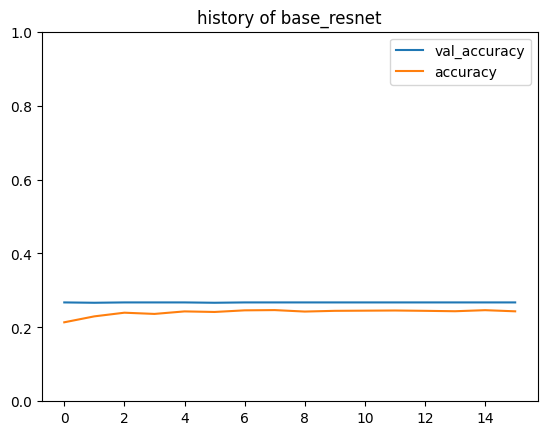

Loading history of base_resnet


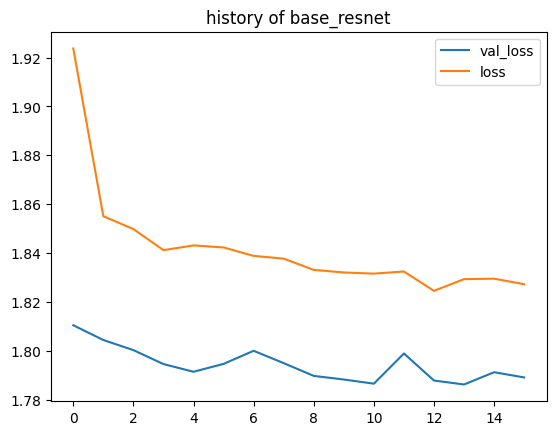

In [ ]:
plot_object(["val_accuracy", "accuracy"])
plot_object(["val_loss", "loss"], None, None)

### Adjusting head architecture - Flattening instead of GlobalAveragePooling2D

In [ ]:
set_save_paths(f"flatten_resnet")
base_model = tf.keras.applications.ResNet50(
    include_top=False,
    input_shape=image_shape,
    weights='imagenet'
)

base_model.trainable = False

INPUTS = tf.keras.Input(shape=image_shape)
L = tfl.Rescaling(1./255)(INPUTS)
L = base_model(L, training=False)
L = tfl.Flatten()(L)
L = tfl.Dense(128, activation='relu')(L)
L = tfl.Dropout(0.58)(L)
OUTPUTS = tfl.Dense(num_classes, activation='softmax')(L)

model = tf.keras.Model(INPUTS, OUTPUTS)

# load_parameters(model)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

cp_callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path, save_weights_only=True, verbose=0)
es_callback = tf.keras.callbacks.EarlyStopping(
    monitor='loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    used_train_ds,
    validation_data=used_val_ds,
    epochs=20,
    callbacks=[cp_callback, es_callback],
    verbose=1
)

save_object(history)

Save path now belongs to flatten_resnet
Epoch 1/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 37s 330ms/step - accuracy: 0.2121 - loss: 1.9617 - val_accuracy: 0.2665 - val_loss: 1.8197
Epoch 2/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 10s 143ms/step - accuracy: 0.2445 - loss: 1.8666 - val_accuracy: 0.2675 - val_loss: 1.8036
Epoch 3/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 10s 143ms/step - accuracy: 0.2465 - loss: 1.8575 - val_accuracy: 0.2675 - val_loss: 1.8125
Epoch 4/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 40s 570ms/step - accuracy: 0.2458 - loss: 1.8537 - val_accuracy: 0.2675 - val_loss: 1.8118
Epoch 5/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 54s 767ms/step - accuracy: 0.2447 - loss: 1.8517 - val_accuracy: 0.2675 - val_loss: 1.7963
Epoch 6/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 52s 738ms/step - accuracy: 0.2443 - loss: 1.8453 - val_accuracy: 0.2675 - val_loss: 1.7962
Epoch 7/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 56s 792ms/step - accuracy: 0.2456 - loss: 1.8434 - val_accuracy: 0.2675 - val_loss: 1.8209
Epoch 8/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 33s 465ms/step - ac

Loading history of flatten_resnet


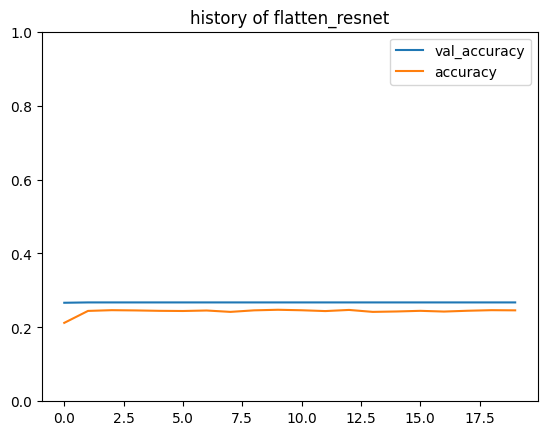

Loading history of flatten_resnet


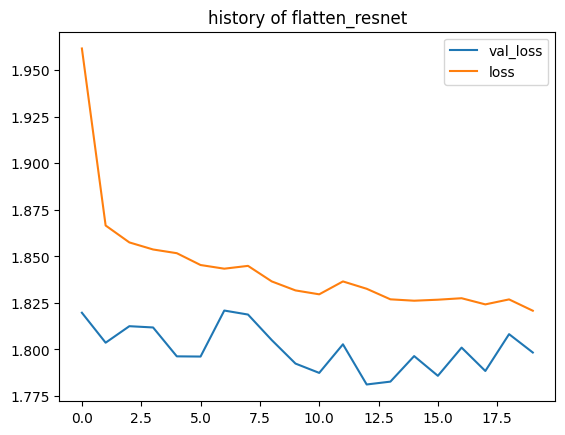

In [ ]:
plot_object(["val_accuracy", "accuracy"])
plot_object(["val_loss", "loss"], None, None)

Slight loss decrease, but not worth the performance tradeoff

### Adjusting head architecture - More dense layers

Save path now belongs to dense_resnet
Epoch 1/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 20s 197ms/step - accuracy: 0.1802 - loss: 1.9155 - val_accuracy: 0.2675 - val_loss: 1.8123
Epoch 2/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 11s 153ms/step - accuracy: 0.2183 - loss: 1.8715 - val_accuracy: 0.2675 - val_loss: 1.8127
Epoch 3/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 11s 153ms/step - accuracy: 0.2280 - loss: 1.8517 - val_accuracy: 0.2675 - val_loss: 1.7950
Epoch 4/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 11s 155ms/step - accuracy: 0.2278 - loss: 1.8459 - val_accuracy: 0.2665 - val_loss: 1.7946
Epoch 5/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 11s 150ms/step - accuracy: 0.2337 - loss: 1.8323 - val_accuracy: 0.2702 - val_loss: 1.7802
Epoch 6/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 11s 157ms/step - accuracy: 0.2460 - loss: 1.8269 - val_accuracy: 0.2684 - val_loss: 1.7747
Epoch 7/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 10s 142ms/step - accuracy: 0.2443 - loss: 1.8208 - val_accuracy: 0.2684 - val_loss: 1.7698
Epoch 8/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 11s 148ms/step - accu

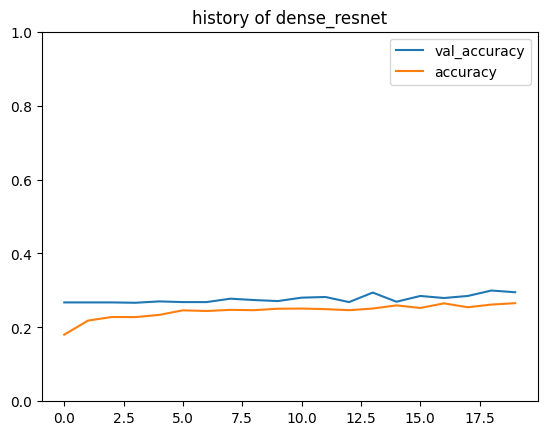

Loading history of dense_resnet


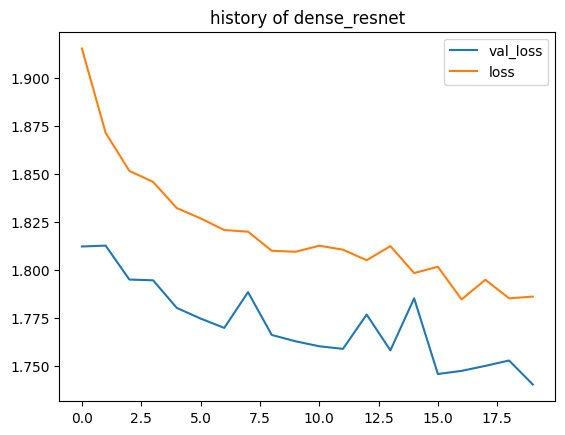

In [ ]:
set_save_paths(f"dense_resnet")
base_model = tf.keras.applications.ResNet50(
    include_top=False,
    input_shape=image_shape,
    weights='imagenet'
)

base_model.trainable = False

INPUTS = tf.keras.Input(shape=image_shape)
L = tfl.Rescaling(1./255)(INPUTS)
L = base_model(L, training=False)
L = tfl.GlobalAveragePooling2D()(L)
L = tfl.Dense(128, activation='relu')(L)
L = tfl.Dense(64, activation='relu')(L)
L = tfl.Dropout(0.58)(L)
OUTPUTS = tfl.Dense(num_classes, activation='softmax')(L)

model = tf.keras.Model(INPUTS, OUTPUTS)

# load_parameters(model)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

cp_callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path, save_weights_only=True, verbose=0)
es_callback = tf.keras.callbacks.EarlyStopping(
    monitor='loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    used_train_ds,
    validation_data=used_val_ds,
    epochs=20,
    callbacks=[cp_callback, es_callback],
    verbose=1
)

save_object(history)
plot_object(["val_accuracy", "accuracy"])
plot_object(["val_loss", "loss"], None, None)

This actually did somewhat better

### Backbone choice

Save path now belongs to base_MobileNetV2


C:\Users\User\AppData\Local\Temp\ipykernel_2816\1825771462.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


No parameters found, no parameters loaded from base_MobileNetV2
Epoch 1/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 15s 147ms/step - accuracy: 0.2434 - loss: 1.9580 - val_accuracy: 0.3051 - val_loss: 1.7173
Epoch 2/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 13s 187ms/step - accuracy: 0.3019 - loss: 1.7316 - val_accuracy: 0.3290 - val_loss: 1.6868
Epoch 3/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 7s 97ms/step - accuracy: 0.3393 - loss: 1.6634 - val_accuracy: 0.3346 - val_loss: 1.6695
Epoch 4/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 7s 93ms/step - accuracy: 0.3660 - loss: 1.6048 - val_accuracy: 0.3456 - val_loss: 1.6473
Epoch 5/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 7s 94ms/step - accuracy: 0.3891 - loss: 1.5571 - val_accuracy: 0.3594 - val_loss: 1.6310
Epoch 6/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 7s 92ms/step - accuracy: 0.4118 - loss: 1.5055 - val_accuracy: 0.3621 - val_loss: 1.6268
Epoch 7/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 12s 167ms/step - accuracy: 0.4489 - loss: 1.4464 - val_accuracy: 0.3741 - val_loss: 1.6246
Epoch 8/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 17s

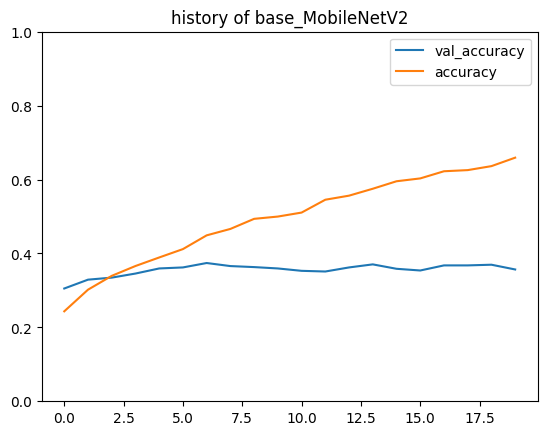

Loading history of base_MobileNetV2


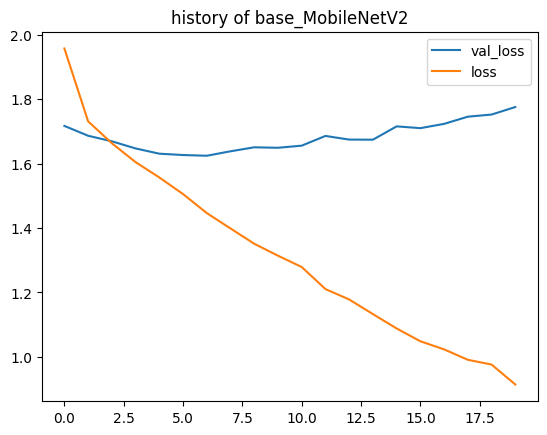

In [ ]:
i = "MobileNetV2"
set_save_paths(f"base_{i}")
base_model = None
base_model = tf.keras.applications.MobileNetV2(
    include_top=False,
    input_shape=image_shape,
    weights='imagenet'
)

base_model.trainable = False # freeze weights

INPUTS = tf.keras.Input(shape=image_shape)
L = tfl.Rescaling(1./255)(INPUTS)
L = base_model(L, training=False) # freeze batchnorms and dropouts
L = tfl.GlobalAveragePooling2D()(L)
L = tfl.Dense(128, activation='relu')(L)
L = tfl.Dropout(0.58)(L)
OUTPUTS = tfl.Dense(num_classes, activation='softmax')(L)

model = tf.keras.Model(INPUTS, OUTPUTS)

load_parameters(model)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

cp_callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path, save_weights_only=True, verbose=0)
es_callback = tf.keras.callbacks.EarlyStopping(
    monitor='loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    used_train_ds,
    validation_data=used_val_ds,
    epochs=20,
    callbacks=[cp_callback, es_callback],
    verbose=1
)

save_object(history)

plot_object(["val_accuracy", "accuracy"])
plot_object(["val_loss", "loss"], None, None)

In [ ]:
model.evaluate(used_val_ds, return_dict=True)

17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.3566 - loss: 1.7760


{'accuracy': 0.35661765933036804, 'loss': 1.7760318517684937}

### Unfreeze

Save path now belongs to last_block_MobileNetV2


C:\Users\User\AppData\Local\Temp\ipykernel_2816\1764096414.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


Loading parameters of base_MobileNetV2 (Custom)
Epoch 1/10


c:\Users\User\Documents\GitHub\ml-with-images\.venv\Lib\site-packages\keras\src\saving\saving_lib.py:643: UserWarning: A total of 2 objects could not be loaded. Example error message for object <Dense name=dense_19, built=True>:

The shape of the target variable and the shape of the target value in `variable.assign(value)` must match. variable.shape=(128, 64), Received: value.shape=(128, 7). Target variable: <Variable path=dense_19/kernel, shape=(128, 64), dtype=float32, value=[[-0.14682643 -0.16773446  0.00163302 ...  0.16077311 -0.04131314
  -0.09641728]
 [-0.15260033 -0.03750657  0.0428824  ... -0.04177709 -0.13308677
   0.12549533]
 [-0.04132831  0.10666309 -0.05087289 ...  0.15516387 -0.04020493
  -0.12483281]
 ...
 [-0.08942419  0.0075461   0.00588071 ... -0.1154089   0.12711973
   0.17648087]
 [-0.12230118  0.10558532  0.11499248 ...  0.02884951  0.06065151
   0.17494677]
 [-0.1547658  -0.12456678 -0.07090996 ...  0.09965508 -0.00946543
   0.11399727]]>

List of objects that cou

71/71 ━━━━━━━━━━━━━━━━━━━━ 18s 168ms/step - accuracy: 0.1699 - loss: 2.5413 - val_accuracy: 0.2325 - val_loss: 1.9464
Epoch 2/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 10s 137ms/step - accuracy: 0.2504 - loss: 1.9593 - val_accuracy: 0.2757 - val_loss: 1.9565
Epoch 3/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 9s 130ms/step - accuracy: 0.2841 - loss: 1.8145 - val_accuracy: 0.2904 - val_loss: 1.9842
Epoch 4/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 10s 139ms/step - accuracy: 0.3171 - loss: 1.7259 - val_accuracy: 0.3006 - val_loss: 1.9921
Epoch 5/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 10s 142ms/step - accuracy: 0.3741 - loss: 1.6112 - val_accuracy: 0.3097 - val_loss: 1.9208
Epoch 6/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 10s 146ms/step - accuracy: 0.3996 - loss: 1.5451 - val_accuracy: 0.3116 - val_loss: 1.8934
Epoch 7/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 10s 135ms/step - accuracy: 0.4333 - loss: 1.4728 - val_accuracy: 0.3070 - val_loss: 2.0473
Epoch 8/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 10s 146ms/step - accuracy: 0.4850 - loss: 1.3743 - val_accuracy: 0.3162

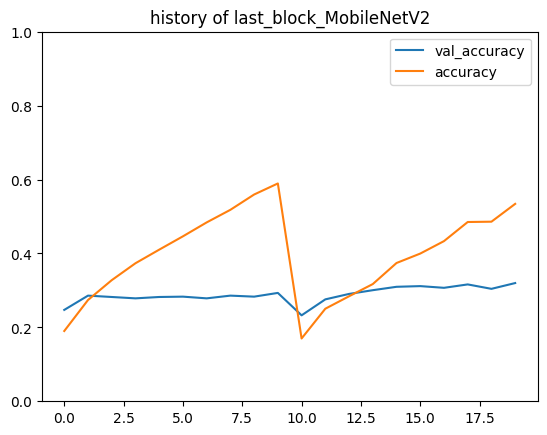

Loading history of last_block_MobileNetV2


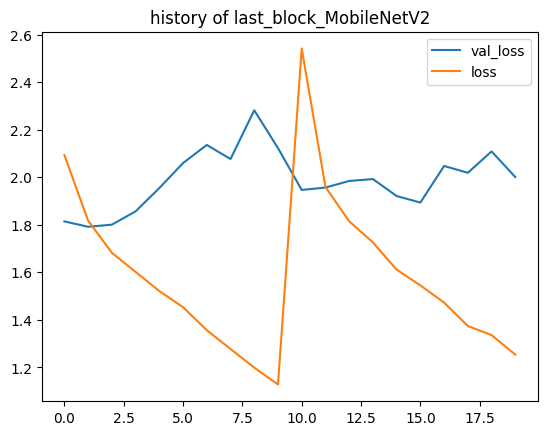

In [ ]:
set_save_paths(f"last_block_MobileNetV2")
base_model = tf.keras.applications.MobileNetV2(
    include_top=False,
    input_shape=image_shape,
    weights='imagenet'
)

INPUTS = tf.keras.Input(shape=image_shape)
L = tfl.Rescaling(1./255)(INPUTS)
L = base_model(L, training=False)
L = tfl.GlobalAveragePooling2D()(L)
L = tfl.Dense(128, activation='relu')(L)
L = tfl.Dense(64, activation='relu')(L)
L = tfl.Dropout(0.58)(L)
OUTPUTS = tfl.Dense(num_classes, activation='softmax')(L)

model = tf.keras.Model(INPUTS, OUTPUTS)

load_parameters(model, custom_model_name="base_MobileNetV2")

cp_callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path, save_weights_only=True, verbose=0)
es_callback = tf.keras.callbacks.EarlyStopping(
    monitor='loss',
    patience=3,
    restore_best_weights=True
)

base_model.trainable = True
fine_tune_at = 140  # unfreeze from this layer onwards
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# lower lr
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

history = model.fit(
    used_train_ds,
    validation_data=used_val_ds,
    epochs=10,
    callbacks=[cp_callback, es_callback],
    verbose=1
)

save_object(history)
plot_object(["val_accuracy", "accuracy"])
plot_object(["val_loss", "loss"], None, None)

In [36]:
model.evaluate(used_train_ds, return_dict=True), model.evaluate(used_val_ds, return_dict=True)

71/71 ━━━━━━━━━━━━━━━━━━━━ 7s 95ms/step - accuracy: 0.3352 - loss: 1.7949
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - accuracy: 0.3199 - loss: 2.0007


({'accuracy': 0.33516725897789, 'loss': 1.7949063777923584},
 {'accuracy': 0.31985294818878174, 'loss': 2.0006701946258545})

### More unfreezing

In [1]:
set_save_paths(f"fulltrain_MobileNetV2")
base_model = tf.keras.applications.MobileNetV2(
    include_top=False,
    input_shape=image_shape,
    weights='imagenet'
)

INPUTS = tf.keras.Input(shape=image_shape)
L = tfl.Rescaling(1./255)(INPUTS)
L = base_model(L, training=False)
L = tfl.GlobalAveragePooling2D()(L)
L = tfl.Dense(128, activation='relu')(L)
L = tfl.Dense(64, activation='relu')(L)
L = tfl.Dropout(0.58)(L)
OUTPUTS = tfl.Dense(num_classes, activation='softmax')(L)

model = tf.keras.Model(INPUTS, OUTPUTS)

load_parameters(model, custom_model_name="base_MobileNetV2")

cp_callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path, save_weights_only=True, verbose=0)
es_callback = tf.keras.callbacks.EarlyStopping(
    monitor='loss',
    patience=3,
    restore_best_weights=True
)

base_model.trainable = True

# lower lr
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

history = model.fit(
    used_train_ds,
    validation_data=used_val_ds,
    epochs=10,
    callbacks=[cp_callback, es_callback],
    verbose=1
)

save_object(history)
plot_object(["val_accuracy", "accuracy"])
plot_object(["val_loss", "loss"], None, None)
model.evaluate(used_train_ds, return_dict=True), model.evaluate(used_val_ds, return_dict=True)

NameError: name 'set_save_paths' is not defined

We can conclude freezing the last block during initial training helps more with training speed and loss

### Data augmentation

Save path now belongs to finalized_MobileNetV2


C:\Users\User\AppData\Local\Temp\ipykernel_19788\3097937978.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(
c:\Users\User\Documents\GitHub\ml-with-images\.venv\Lib\site-packages\keras\src\layers\preprocessing\tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Loading parameters of last_block_MobileNetV2 (Custom)
Epoch 1/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 26s 239ms/step - accuracy: 0.3066 - loss: 1.8455 - val_accuracy: 0.3456 - val_loss: 1.8179
Epoch 2/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 15s 209ms/step - accuracy: 0.3132 - loss: 1.7809 - val_accuracy: 0.3189 - val_loss: 2.1457
Epoch 3/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 15s 215ms/step - accuracy: 0.3319 - loss: 1.7231 - val_accuracy: 0.3180 - val_loss: 2.0567
Epoch 4/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 15s 207ms/step - accuracy: 0.3512 - loss: 1.6847 - val_accuracy: 0.3107 - val_loss: 2.3104
Epoch 5/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 15s 212ms/step - accuracy: 0.3534 - loss: 1.6694 - val_accuracy: 0.2987 - val_loss: 2.5233
Epoch 6/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 20s 288ms/step - accuracy: 0.3587 - loss: 1.6426 - val_accuracy: 0.3097 - val_loss: 2.4888
Epoch 7/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 15s 205ms/step - accuracy: 0.3684 - loss: 1.6233 - val_accuracy: 0.3336 - val_loss: 2.3782
Epoch 8/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 14s 2

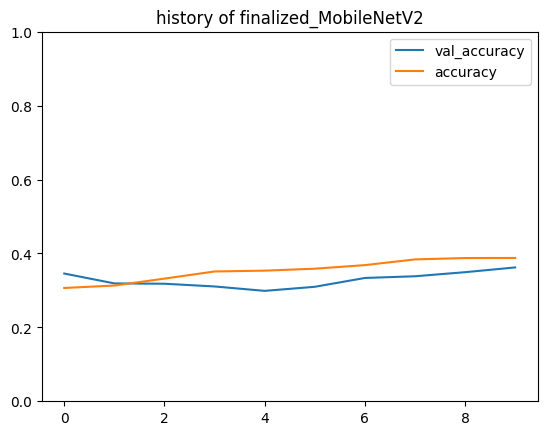

Loading history of finalized_MobileNetV2


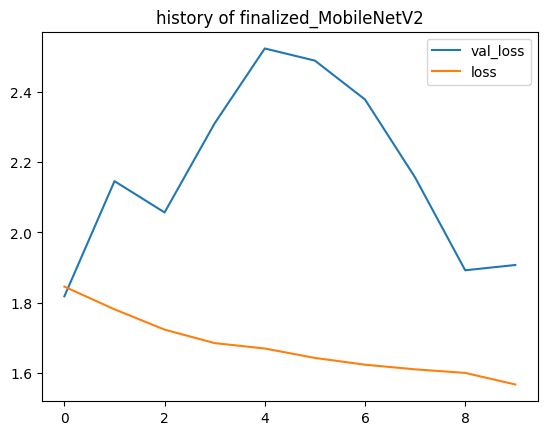

71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step - accuracy: 0.4514 - loss: 1.5154
Train: {'accuracy': 0.4513644278049469, 'loss': 1.515377163887024}
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - accuracy: 0.3621 - loss: 1.9071
Validation: {'accuracy': 0.36213234066963196, 'loss': 1.9070782661437988}


In [11]:
set_save_paths(f"finalized_MobileNetV2")
base_model = tf.keras.applications.MobileNetV2(
    include_top=False,
    input_shape=image_shape,
    weights='imagenet'
)

INPUTS = tf.keras.Input(shape=image_shape)

L = tfl.Rescaling(1./255)(INPUTS)

# augmentation
L = tfl.RandomFlip("horizontal", input_shape=image_shape)(L)
L = tfl.RandomRotation(0.05)(L)
L = tfl.RandomZoom(height_factor=(-0.1, 0))(L)

L = base_model(L, training=False)
L = tfl.GlobalAveragePooling2D()(L)
L = tfl.Dense(128, activation='relu')(L)
L = tfl.Dense(64, activation='relu')(L)
L = tfl.Dropout(0.58)(L)
OUTPUTS = tfl.Dense(num_classes, activation='softmax')(L)

model = tf.keras.Model(INPUTS, OUTPUTS)

load_parameters(model, custom_model_name="last_block_MobileNetV2")

cp_callback = tf.keras.callbacks.ModelCheckpoint(filepath=checkpoint_path, save_weights_only=True, verbose=0)
es_callback = tf.keras.callbacks.EarlyStopping(
    monitor='loss',
    patience=3,
    restore_best_weights=True
)

base_model.trainable = True
fine_tune_at = 140  # unfreeze from this layer onwards
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# lower lr
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

history = model.fit(
    used_train_ds,
    validation_data=used_val_ds,
    epochs=10,
    callbacks=[cp_callback, es_callback],
    verbose=1
)

full_evaluation(model, history)

So far, the model adapts excellently to augmentation (due to previously learnt weights and representations).